In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# 为developer aware计算只考虑有效样本的实验结果

MODEL_NAME_LIST = ["codebert","plbart", "graphcodebert", "unixcoder",  "codet5","cct5"]
cluster_model="developer_aware"
N_CLUSTER=4
for result_time in ["result0", "result1", "result2", "result3", "result4"]:
    for model_name in MODEL_NAME_LIST:
        base_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "base_results.csv")
        lora_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "lora_results.csv")
        outlier_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "outlier_results.csv")

        base_ouput = pd.read_csv(os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "base_output.csv"))[:2037]
        lora_ouput = pd.read_csv(os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "lora_output.csv"))[:2037]
        outlier_ouput = pd.read_csv(os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "outlier_output.csv"))[:2037]

        new_base_performance=calculate_metrics(base_ouput["prob"],base_ouput["prediction_label"],base_ouput["true_label"])
        new_lora_performance=calculate_metrics(lora_ouput["prob"],lora_ouput["prediction_label"],lora_ouput["true_label"])
        new_outlier_performance=calculate_metrics(outlier_ouput["prob"],outlier_ouput["prediction_label"],outlier_ouput["true_label"])

        base_df=pd.read_csv(base_path,index_col=0).drop("new_other")
        lora_df=pd.read_csv(lora_path,index_col=0).drop("new_other")
        outlier_df=pd.read_csv(outlier_path,index_col=0).drop("new_other")

        new_base_df=pd.concat([base_df,pd.DataFrame([new_base_performance],index=["new_all"])])
        new_base_df.index.name="developer"

        new_lora_df=pd.concat([lora_df,pd.DataFrame([new_lora_performance],index=["new_all"])])
        new_lora_df.index.name="developer"

        new_outlier_df=pd.concat([outlier_df,pd.DataFrame([new_outlier_performance],index=["new_all"])])
        new_outlier_df.index.name="developer"

        new_base_df.to_csv(base_path)
        new_lora_df.to_csv(lora_path)
        new_outlier_df.to_csv(outlier_path)


                   base      lora   outlier
codebert       0.354169  0.449093  0.428784
plbart         0.430922  0.464255  0.463389
graphcodebert  0.405080  0.473470  0.446563
unixcoder      0.352239  0.424464  0.401537
codet5         0.399245  0.427553  0.417943
cct5           0.427970  0.458368  0.460670


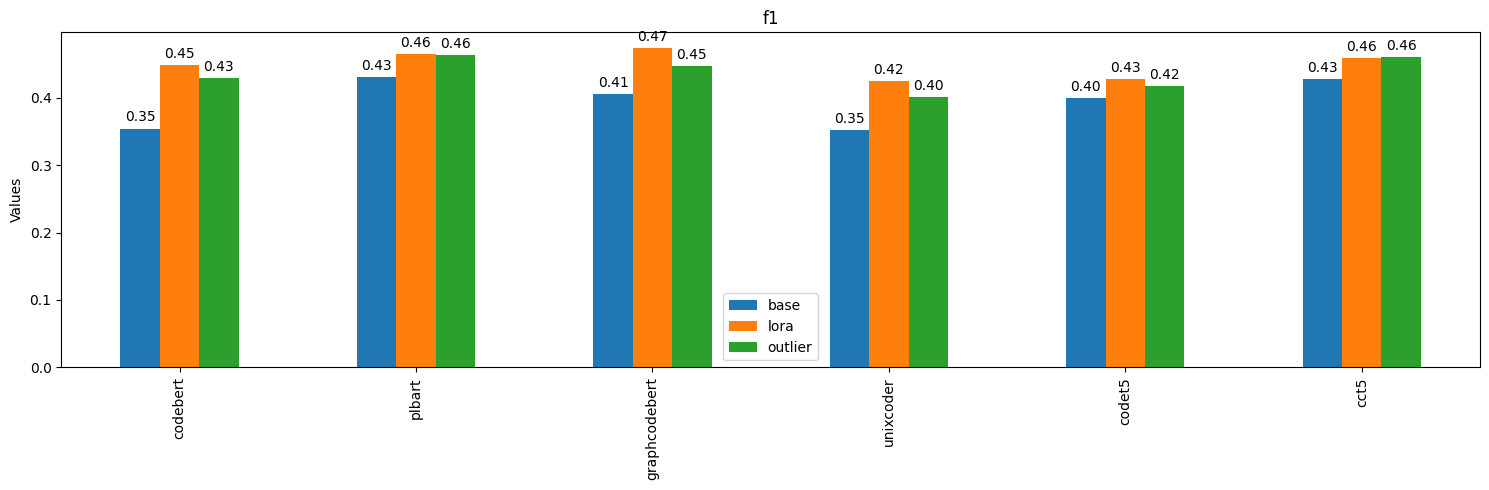

                   base      lora   outlier
codebert       0.553527  0.631035  0.613079
plbart         0.592323  0.651307  0.641133
graphcodebert  0.617095  0.678039  0.657119
unixcoder      0.552307  0.646304  0.617491
codet5         0.601548  0.605778  0.598381
cct5           0.610298  0.664227  0.661302


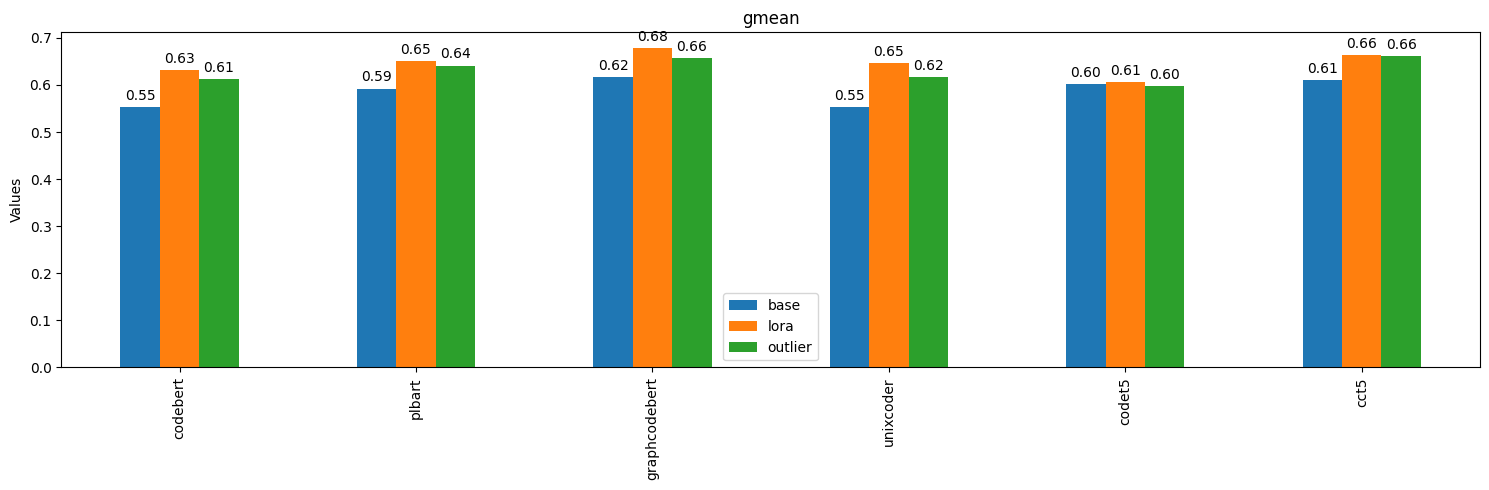

In [24]:
MODEL_NAME_LIST = ["codebert","plbart", "graphcodebert", "unixcoder",  "codet5","cct5"]
cluster_model="developer_aware"
N_CLUSTER=4
for metric in ["f1","gmean"]:
    full_table=[]
    for model_name in MODEL_NAME_LIST:
        v_line=[]
        base_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/average/{model_name}", "base_results.csv")
        lora_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/average/{model_name}", "lora_results.csv")
        outlier_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/average/{model_name}", "outlier_results.csv")

        base_v=pd.read_csv(base_path,index_col=0).loc["new_all"][metric]
        v_line.append(base_v)
        lora_v=pd.read_csv(lora_path,index_col=0).loc["new_all"][metric]
        v_line.append(lora_v)
        outlier_v=pd.read_csv(outlier_path,index_col=0).loc["new_all"][metric]
        v_line.append(outlier_v)
        full_table.append(v_line)
    new_df=pd.DataFrame(data=full_table,index=MODEL_NAME_LIST,columns=["base","lora","outlier"])
    print(new_df)
    ax = new_df.plot.bar(title=metric,figsize=(15,5))
    ax.set_ylabel('Values')

    # 在每个柱子上显示数值
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    plt.tight_layout()
    plt.show()    

In [1]:
# 计算加入Outler Detector后是否会对Lora模型的表现性能产生显著影响
MODEL_NAME_LIST = ["codebert","plbart", "graphcodebert", "unixcoder",  "codet5","cct5"]
CLUSTER_MODEL_LIST = ["developer_aware","Kmean","project_final"]
N_CLUSTER = 4
BASE_MODEL = "concat"
import os
import scipy.stats as stats
import pandas as pd

In [13]:
import scipy.stats as stats
import numpy as np

def cliff_delta(x, y):
    """
    计算 Cliff's delta 效应量：delta = P(X > Y) - P(X < Y)
    参数 x, y 为两个独立样本的一维数组（此处用于配对数据时将其视为两组独立样本）。
    返回 delta 值（范围 -1 ~ 1）。
    """
    n_x = len(x)
    n_y = len(y)
    greater = 0
    less = 0
    for xi in x:
        for yj in y:
            if xi > yj:
                greater += 1
            elif xi < yj:
                less += 1
    delta = (greater - less) / (n_x * n_y)
    return delta

def analyze_performance_trend(before, after, alpha=0.05):
    """
    分析性能变化趋势是否显著

    Parameters:
    - before: 第一组数据（基准/改进前）
    - after: 第二组数据（改进后）
    - alpha: 显著性水平，默认0.05
    
    Returns:
    - t_stat: 检验统计量
    - p_value: p值
    - effect_size: 效应量 (Cliff's delta)
    """

    print("=" * 60)
    print("性能变化趋势分析")
    print("=" * 60)

    before = np.asarray(before, dtype=float)
    after = np.asarray(after, dtype=float)
    differences = after - before

    # 防止除零警告
    with np.errstate(divide='ignore', invalid='ignore'):
        percent_changes = ((after - before) / before) * 100

    print(f"样本数量: {len(before)}")
    print(f"基准组均值: {np.mean(before):.4f}")
    print(f"改进组均值: {np.mean(after):.4f}")
    print(f"平均变化量: {np.mean(differences):.4f}")
    print(f"平均变化百分比: {np.nanmean(percent_changes):.2f}%")

    # 1. 正态性检验（针对差值）
    _, p_norm = stats.shapiro(differences)
    print(f"\n差值正态性检验(Shapiro-Wilk) p值: {p_norm:.4f}")

    # 2. 选择合适的检验方法
    if p_norm > alpha:
        # 使用配对t检验
        t_stat, p_value = stats.ttest_rel(after, before)
        test_used = "配对t检验"
    else:
        # 使用Wilcoxon符号秩检验
        t_stat, p_value = stats.wilcoxon(after, before)
        test_used = "Wilcoxon符号秩检验"

    # 统一使用 Cliff's delta（将 before 和 after 视为两个独立样本）
    effect_size = cliff_delta(after, before)
    effect_name = "Cliff's delta"

    print(f"\n使用的检验方法: {test_used}")
    print(f"检验统计量: {t_stat:.4f}")
    print(f"p值: {p_value:.4f}")
    print(f"效应量 ({effect_name}): {effect_size:.4f}")

    # 3. 趋势方向判断
    mean_change = np.mean(differences)
    direction = "提升" if mean_change > 0 else "下降"
    trend = "正向" if mean_change > 0 else "负向"

    # 4. 结果解释
    if p_value < alpha:
        print(f"\n结论: 性能{direction}是统计显著的 (p < {alpha})")
        print(f"趋势: 显著的{trend}趋势")
    else:
        print(f"\n结论: 性能{direction}不显著 (p ≥ {alpha})")
        print(f"趋势: 无显著趋势")

    return t_stat, p_value

In [19]:
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cliff_delta(x, y):
    """
    计算 Cliff's delta 效应量：delta = P(X > Y) - P(X < Y)
    参数 x, y 为两个独立样本的一维数组。
    返回 delta 值（范围 -1 ~ 1）。
    """
    n_x = len(x)
    n_y = len(y)
    greater = 0
    less = 0
    # 遍历所有配对进行比较（可优化但此处保持清晰）
    for xi in x:
        for yj in y:
            if xi > yj:
                greater += 1
            elif xi < yj:
                less += 1
    delta = (greater - less) / (n_x * n_y)
    return delta

def analyze_performance_trend_Pcode(before, after, alpha=0.05, higher_is_better=True):
    """
    分析性能变化趋势是否显著
    
    Parameters:
    - before: 第一组数据（基准/改进前）
    - after: 第二组数据（改进后）
    - alpha: 显著性水平，默认0.05
    - higher_is_better: 指标是否越高越好，默认True
    
    Returns:
    - 'B': 显著更好
    - 'W': 显著变差  
    - 'N': 无显著差异
    """
    
    print("=" * 60)
    print("性能变化趋势分析")
    print("=" * 60)
    
    # 计算变化量
    differences = after - before
    percent_changes = ((after - before) / before) * 100
    
    # print(f"样本数量: {len(before)}")
    # print(f"基准组均值: {np.mean(before):.4f}")
    # print(f"改进组均值: {np.mean(after):.4f}")
    # print(f"平均变化量: {np.mean(differences):.4f}")
    # print(f"平均变化百分比: {np.mean(percent_changes):.2f}%")
    
    # 1. 正态性检验（针对差值）
    _, p_norm = stats.shapiro(differences)
    print(f"\n差值正态性检验(Shapiro-Wilk) p值: {p_norm:.4f}")
    
    # 2. 选择合适的检验方法
    if p_norm > alpha:
        # 使用配对t检验
        t_stat, p_value = stats.ttest_rel(after, before)
        test_used = "配对t检验"
    else:
        # 使用Wilcoxon符号秩检验
        t_stat, p_value = stats.wilcoxon(after, before)
        test_used = "Wilcoxon符号秩检验"
    
    # 统一使用 Cliff's delta 作为效应量（将 before 和 after 视为两个独立样本）
    effect_size = cliff_delta(after, before)
    
    print(f"\n使用的检验方法: {test_used}")
    print(f"检验统计量: {t_stat:.4f}")
    print(f"p值: {p_value:.4f}")
    print(f"效应量 (Cliff's delta): {effect_size:.4f}")
    
    # 3. 趋势方向判断
    mean_change = np.mean(differences)
    if mean_change > 0:
        direction = "提升"
        trend = "正向"
    else:
        direction = "下降" 
        trend = "负向"
    
    # 4. 确定返回结果
    result_code = 'N'  # 默认无显著差异
    
    if p_value < alpha:
        # 有显著差异
        if higher_is_better:
            # 指标越高越好
            if mean_change > 0:
                result_code = 'B'  # 显著更好
            else:
                result_code = 'W'  # 显著变差
        else:
            # 指标越低越好（如响应时间）
            if mean_change < 0:
                result_code = 'B'  # 显著更好
            else:
                result_code = 'W'  # 显著变差
        
        # print(f"\n结论: 性能{direction}是统计显著的 (p < {alpha})")
        # print(f"趋势: 显著的{trend}趋势")
        # print(f"返回代码: {result_code}")
    else:
        # 无显著差异
        result_code = 'N'
        # print(f"\n结论: 性能{direction}不显著 (p ≥ {alpha})")
        # print(f"趋势: 无显著趋势")
        # print(f"返回代码: {result_code}")
    print(result_code)
    
    return f"{result_code} [{effect_size}]"

In [20]:

### Base To Lora significance
for metric in ["f1","gmean"]:
    significance_table=[]
    for cluster_model in CLUSTER_MODEL_LIST:
        line=[]
        for model_name in MODEL_NAME_LIST:
            base_data=[]
            lora_data=[]
            for result_time in ["result0", "result1", "result2", "result3", "result4"]:
                lora_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "lora_results.csv")
                base_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "base_results.csv")

                lora_data.append(pd.read_csv(lora_path,index_col=0).loc["all"][metric])
                base_data.append(pd.read_csv(base_path,index_col=0).loc["all"][metric])

            # t_stat,p_value=stats.ttest_rel(base_data,lora_data)
            Pcode=analyze_performance_trend_Pcode(np.array(base_data),np.array(lora_data))
            line.append(Pcode)
        significance_table.append(line)
    print(f"for {metric} table is {significance_table}")
    pd.DataFrame(significance_table,index=CLUSTER_MODEL_LIST,columns=MODEL_NAME_LIST).to_csv(f"result/RQ3/base_to_lora_significance_compare_{metric}.csv")
##这块结果显示加入Outlier Detector之后的差异是不显著的

性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.0277

使用的检验方法: Wilcoxon符号秩检验
检验统计量: 0.0000
p值: 0.0625
效应量 (Cliff's delta): 1.0000
N
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.3318

使用的检验方法: 配对t检验
检验统计量: 11.1661
p值: 0.0004
效应量 (Cliff's delta): 0.9200
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.0495

使用的检验方法: Wilcoxon符号秩检验
检验统计量: 0.0000
p值: 0.0625
效应量 (Cliff's delta): 1.0000
N
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.7049

使用的检验方法: 配对t检验
检验统计量: 17.4965
p值: 0.0001
效应量 (Cliff's delta): 0.9200
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.3748

使用的检验方法: 配对t检验
检验统计量: 4.2839
p值: 0.0128
效应量 (Cliff's delta): 0.8400
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.6735

使用的检验方法: 配对t检验
检验统计量: 3.6721
p值: 0.0214
效应量 (Cliff's delta): 0.6000
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.9041

使用的检验方法: 配对t检验
检验统计量: 8.2890
p值: 0.0012
效应量 (Cliff's delta): 1.0000
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.4669

使用的检验方法: 配对t检验
检验统计量: 3.3332
p值: 0.0290
效应量 (Cliff's delta): 0.8400
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.7860

使用的检验方法: 配对t检验
检验统计量: 7.59

In [12]:
### Base To Lora Pvalue
for metric in ["f1","gmean"]:
    significance_table=[]
    for cluster_model in CLUSTER_MODEL_LIST:
        line=[]
        for model_name in MODEL_NAME_LIST:
            base_data=[]
            lora_data=[]
            for result_time in ["result0", "result1", "result2", "result3", "result4"]:
                lora_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "lora_results.csv")
                base_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "base_results.csv")

                lora_data.append(pd.read_csv(lora_path,index_col=0).loc["all"][metric])
                base_data.append(pd.read_csv(base_path,index_col=0).loc["all"][metric])

            # t_stat,p_value=stats.ttest_rel(base_data,lora_data)
            t,p_value=analyze_performance_trend(np.array(base_data),np.array(lora_data))
            line.append(round(p_value,4))
        significance_table.append(line)
    print(f"for {metric} table is {significance_table}")
    # pd.DataFrame(significance_table,index=CLUSTER_MODEL_LIST,columns=MODEL_NAME_LIST).to_csv(f"result/RQ3/base_to_lora_pvalue_compare_{metric}.csv")
##这块结果显示加入Outlier Detector之后的差异是不显著的

性能变化趋势分析
样本数量: 5
基准组均值: 0.4227
改进组均值: 0.4486
平均变化量: 0.0259
平均变化百分比: 6.14%

差值正态性检验(Shapiro-Wilk) p值: 0.0277

使用的检验方法: Wilcoxon符号秩检验
检验统计量: 0.0000
p值: 0.0625
效应量 (Paired Cliff's δ): 1.0000

结论: 性能提升不显著 (p ≥ 0.05)
趋势: 无显著趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4715
改进组均值: 0.4800
平均变化量: 0.0085
平均变化百分比: 1.79%

差值正态性检验(Shapiro-Wilk) p值: 0.3318

使用的检验方法: 配对t检验
检验统计量: 11.1661
p值: 0.0004
效应量 (Cohen's d_z): 4.9936

结论: 性能提升是统计显著的 (p < 0.05)
趋势: 显著的正向趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4532
改进组均值: 0.4725
平均变化量: 0.0192
平均变化百分比: 4.25%

差值正态性检验(Shapiro-Wilk) p值: 0.0495

使用的检验方法: Wilcoxon符号秩检验
检验统计量: 0.0000
p值: 0.0625
效应量 (Paired Cliff's δ): 1.0000

结论: 性能提升不显著 (p ≥ 0.05)
趋势: 无显著趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4549
改进组均值: 0.4725
平均变化量: 0.0177
平均变化百分比: 3.88%

差值正态性检验(Shapiro-Wilk) p值: 0.7049

使用的检验方法: 配对t检验
检验统计量: 17.4965
p值: 0.0001
效应量 (Cohen's d_z): 7.8247

结论: 性能提升是统计显著的 (p < 0.05)
趋势: 显著的正向趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4621
改进组均值: 0.4707
平均变化量: 0.0086
平均变化百分比: 1.86%

差值正态性检验(Shapiro-Wilk) p值: 0.3748

使用的检验方法: 配对t检验
检验

In [14]:

### Lora To outlier pvalue
for metric in ["f1","gmean"]:
    significance_table=[]
    for cluster_model in CLUSTER_MODEL_LIST:
        line=[]
        for model_name in MODEL_NAME_LIST:
            lora_data=[]
            outlier_data=[]
            for result_time in ["result0", "result1", "result2", "result3", "result4"]:
                lora_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "lora_results.csv")
                outlier_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "outlier_results.csv")

                lora_data.append(pd.read_csv(lora_path,index_col=0).loc["all"][metric].item())
                outlier_data.append(pd.read_csv(outlier_path,index_col=0).loc["all"][metric].item())

            # t_stat,p_value=stats.ttest_rel(lora_data,outlier_data)
            t_stat,p_value=analyze_performance_trend(np.array(lora_data),np.array(outlier_data))
            line.append(round(float(p_value),4))
        significance_table.append(line)
    print(f"for {metric} table is {significance_table}")
    # pd.DataFrame(significance_table,index=CLUSTER_MODEL_LIST,columns=MODEL_NAME_LIST).to_csv(f"result/RQ3/lora_to_outlier_pvalue_compare_{metric}.csv")
##这块结果显示加入Outlier Detector之后的差异是不显著的

性能变化趋势分析
样本数量: 5
基准组均值: 0.4486
改进组均值: 0.4430
平均变化量: -0.0056
平均变化百分比: -1.24%

差值正态性检验(Shapiro-Wilk) p值: 0.2186

使用的检验方法: 配对t检验
检验统计量: -4.7516
p值: 0.0090
效应量 (Cliff's delta): -0.5600

结论: 性能下降是统计显著的 (p < 0.05)
趋势: 显著的负向趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4800
改进组均值: 0.4799
平均变化量: -0.0001
平均变化百分比: -0.02%

差值正态性检验(Shapiro-Wilk) p值: 0.5115

使用的检验方法: 配对t检验
检验统计量: -0.1360
p值: 0.8984
效应量 (Cliff's delta): 0.0400

结论: 性能下降不显著 (p ≥ 0.05)
趋势: 无显著趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4725
改进组均值: 0.4648
平均变化量: -0.0077
平均变化百分比: -1.63%

差值正态性检验(Shapiro-Wilk) p值: 0.1273

使用的检验方法: 配对t检验
检验统计量: -3.0590
p值: 0.0377
效应量 (Cliff's delta): -0.7600

结论: 性能下降是统计显著的 (p < 0.05)
趋势: 显著的负向趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4725
改进组均值: 0.4664
平均变化量: -0.0061
平均变化百分比: -1.30%

差值正态性检验(Shapiro-Wilk) p值: 0.7451

使用的检验方法: 配对t检验
检验统计量: -4.9513
p值: 0.0078
效应量 (Cliff's delta): -0.4400

结论: 性能下降是统计显著的 (p < 0.05)
趋势: 显著的负向趋势
性能变化趋势分析
样本数量: 5
基准组均值: 0.4707
改进组均值: 0.4682
平均变化量: -0.0025
平均变化百分比: -0.53%

差值正态性检验(Shapiro-Wilk) p值: 0.6336

使用的检验方法: 配对t检验


In [ ]:

### Lora To outlier Significance
for metric in ["f1","gmean"]:
    significance_table=[]
    for cluster_model in CLUSTER_MODEL_LIST:
        line=[]
        for model_name in MODEL_NAME_LIST:
            lora_data=[]
            outlier_data=[]
            for result_time in ["result0", "result1", "result2", "result3", "result4"]:
                lora_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "lora_results.csv")
                outlier_path = os.path.join(f"result/{cluster_model}/{str(N_CLUSTER)}/{result_time}/{model_name}", "outlier_results.csv")

                lora_data.append(pd.read_csv(lora_path,index_col=0).loc["all"][metric].item())
                outlier_data.append(pd.read_csv(outlier_path,index_col=0).loc["all"][metric].item())

            # t_stat,p_value=stats.ttest_rel(lora_data,outlier_data)
            Pcode=analyze_performance_trend_Pcode(np.array(lora_data),np.array(outlier_data))
            line.append(Pcode)
        significance_table.append(line)
    print(f"for {metric} table is {significance_table}")
    pd.DataFrame(significance_table,index=CLUSTER_MODEL_LIST,columns=MODEL_NAME_LIST).to_csv(f"result/RQ3/lora_to_outlier_significance_compare_{metric}.csv")
##这块结果显示加入Outlier Detector之后的差异是不显著的

性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.2186

使用的检验方法: 配对t检验
检验统计量: -4.7516
p值: 0.0090
效应量 (Cliff's delta): -0.5600
W
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.5115

使用的检验方法: 配对t检验
检验统计量: -0.1360
p值: 0.8984
效应量 (Cliff's delta): 0.0400
N
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.1273

使用的检验方法: 配对t检验
检验统计量: -3.0590
p值: 0.0377
效应量 (Cliff's delta): -0.7600
W
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.7451

使用的检验方法: 配对t检验
检验统计量: -4.9513
p值: 0.0078
效应量 (Cliff's delta): -0.4400
W
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.6336

使用的检验方法: 配对t检验
检验统计量: -2.2628
p值: 0.0864
效应量 (Cliff's delta): -0.3200
N
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.5276

使用的检验方法: 配对t检验
检验统计量: 1.0876
p值: 0.3379
效应量 (Cliff's delta): 0.2000
N
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.7183

使用的检验方法: 配对t检验
检验统计量: 1.2068
p值: 0.2940
效应量 (Cliff's delta): 0.2000
N
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.8237

使用的检验方法: 配对t检验
检验统计量: 18.0150
p值: 0.0001
效应量 (Cliff's delta): 0.8400
B
性能变化趋势分析

差值正态性检验(Shapiro-Wilk) p值: 0.1165

使用的检验方法: 配对t检验
检验统计量: 3.9160
p值: 0